<a href="https://colab.research.google.com/github/mathanbabumk21/DAA/blob/main/DAA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Text: AABAACAADAABAABA
Pattern: AABA

Naive Search
Matches: [0, 9, 12]
Comparisons: 30

KMP Search
Matches: [0, 9, 12]
Comparisons: 18

Rabin-Karp
Matches: [0, 9, 12]
Comparisons: 12

     Pattern      Naive        KMP         RK
--------------------------------------------------
          AB      12483      10000       1304
        ABCD      13286      10000        239
      ABCDAB      13336      10011        145
    ABCDABCD      13337      10012        139


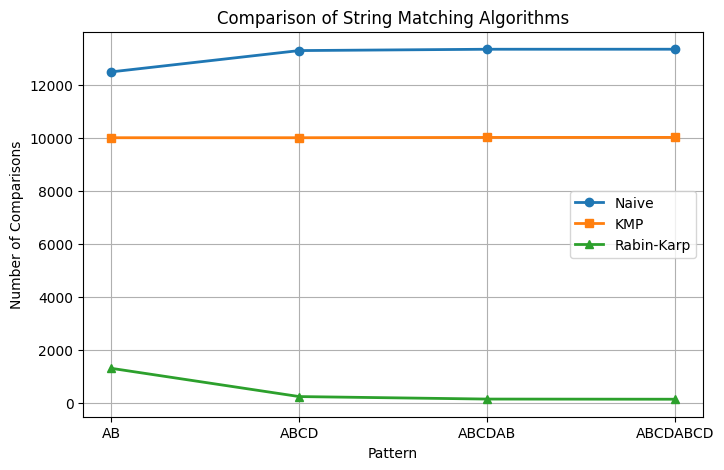

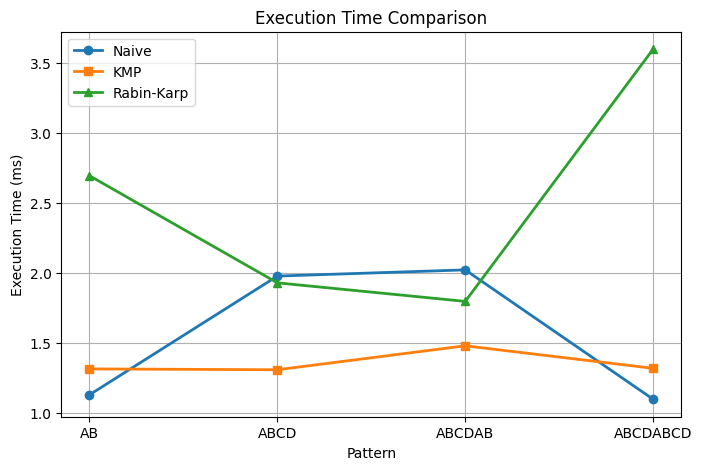

In [1]:
import time
import random
import matplotlib.pyplot as plt


# ---------------- Naive Search ----------------
def naive_search(text, pattern):
    n, m = len(text), len(pattern)
    matches = []
    comparisons = 0

    for i in range(n - m + 1):
        j = 0
        while j < m:
            comparisons += 1
            if text[i + j] != pattern[j]:
                break
            j += 1

        if j == m:
            matches.append(i)

    return matches, comparisons


# ---------------- Compute LPS ----------------
def compute_lps(pattern):
    m = len(pattern)
    lps = [0] * m
    length = 0
    i = 1

    while i < m:
        if pattern[i] == pattern[length]:
            length += 1
            lps[i] = length
            i += 1
        elif length != 0:
            length = lps[length - 1]
        else:
            lps[i] = 0
            i += 1

    return lps


# ---------------- KMP Search ----------------
def kmp_search(text, pattern):
    n, m = len(text), len(pattern)
    lps = compute_lps(pattern)

    matches = []
    comparisons = 0

    i = j = 0

    while i < n:
        comparisons += 1

        if text[i] == pattern[j]:
            i += 1
            j += 1

        if j == m:
            matches.append(i - j)
            j = lps[j - 1]

        elif i < n and text[i] != pattern[j]:
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1

    return matches, comparisons


# ---------------- Rabin-Karp ----------------
def rabin_karp(text, pattern, q=101):
    n, m = len(text), len(pattern)
    d = 256

    h = pow(d, m - 1, q)
    p_hash = 0
    t_hash = 0

    matches = []
    comparisons = 0

    for i in range(m):
        p_hash = (d * p_hash + ord(pattern[i])) % q
        t_hash = (d * t_hash + ord(text[i])) % q

    for s in range(n - m + 1):

        if p_hash == t_hash:
            for k in range(m):
                comparisons += 1
                if text[s + k] != pattern[k]:
                    break
            else:
                matches.append(s)

        if s < n - m:
            t_hash = (d * (t_hash - ord(text[s]) * h) + ord(text[s + m])) % q

            if t_hash < 0:
                t_hash += q

    return matches, comparisons


# ---------------- Main Example ----------------

text = "AABAACAADAABAABA"
pattern = "AABA"

print("Text:", text)
print("Pattern:", pattern)

m1, c1 = naive_search(text, pattern)
m2, c2 = kmp_search(text, pattern)
m3, c3 = rabin_karp(text, pattern)

print("\nNaive Search")
print("Matches:", m1)
print("Comparisons:", c1)

print("\nKMP Search")
print("Matches:", m2)
print("Comparisons:", c2)

print("\nRabin-Karp")
print("Matches:", m3)
print("Comparisons:", c3)


# ---------------- Performance Comparison ----------------

text_large = "".join(random.choices("ABCD", k=10000))
patterns = ["AB", "ABCD", "ABCDAB", "ABCDABCD"]

naive_comp = []
kmp_comp = []
rk_comp = []

naive_time = []
kmp_time = []
rk_time = []

print(f"\n{'Pattern':>12} {'Naive':>10} {'KMP':>10} {'RK':>10}")
print("-" * 50)

for p in patterns:

    # Naive
    start = time.perf_counter()
    for _ in range(100):
        _, c1 = naive_search(text_large, p)
    t1 = (time.perf_counter() - start) / 100 * 1000

    # KMP
    start = time.perf_counter()
    for _ in range(100):
        _, c2 = kmp_search(text_large, p)
    t2 = (time.perf_counter() - start) / 100 * 1000

    # Rabin-Karp
    start = time.perf_counter()
    for _ in range(100):
        _, c3 = rabin_karp(text_large, p)
    t3 = (time.perf_counter() - start) / 100 * 1000

    naive_comp.append(c1)
    kmp_comp.append(c2)
    rk_comp.append(c3)

    naive_time.append(t1)
    kmp_time.append(t2)
    rk_time.append(t3)

    print(f"{p:>12} {c1:>10} {c2:>10} {c3:>10}")


# ---------------- Graph 1 : Comparisons ----------------

plt.figure(figsize=(8,5))

plt.plot(patterns, naive_comp, marker='o', linewidth=2, label="Naive")
plt.plot(patterns, kmp_comp, marker='s', linewidth=2, label="KMP")
plt.plot(patterns, rk_comp, marker='^', linewidth=2, label="Rabin-Karp")

plt.title("Comparison of String Matching Algorithms")
plt.xlabel("Pattern")
plt.ylabel("Number of Comparisons")
plt.legend()
plt.grid(True)

plt.show()


# ---------------- Graph 2 : Execution Time ----------------

plt.figure(figsize=(8,5))

plt.plot(patterns, naive_time, marker='o', linewidth=2, label="Naive")
plt.plot(patterns, kmp_time, marker='s', linewidth=2, label="KMP")
plt.plot(patterns, rk_time, marker='^', linewidth=2, label="Rabin-Karp")

plt.title("Execution Time Comparison")
plt.xlabel("Pattern")
plt.ylabel("Execution Time (ms)")
plt.legend()
plt.grid(True)

plt.show()